In [1]:
import sbibm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tqdm
import random

import torch
import torch.distributions as D

from modules.dense import DenseEncoder1LayerGaussian
from modules.custom_lr_scheduler import CustomOptim

### Show Two Moon

In [2]:
torch.manual_seed(1235)
random.seed(1235)
np.random.seed(1235)

In [3]:
task = sbibm.get_task("two_moons")

In [4]:
prior = task.get_prior()
simulator = task.get_simulator()

In [5]:
thetas = prior(num_samples=100)
xs = simulator(thetas)

In [6]:
thetas.shape, xs.shape

(torch.Size([100, 2]), torch.Size([100, 2]))

In [7]:
observation = task.get_observation(num_observation=1)
reference_samples = task.get_reference_posterior_samples(num_observation=1)

In [8]:
observation.shape, reference_samples.shape

(torch.Size([1, 2]), torch.Size([10000, 2]))

In [9]:
observation

tensor([[-0.6397,  0.1623]])

In [10]:
reference_samples.mean(dim=0)

tensor([-0.1157,  0.1151])

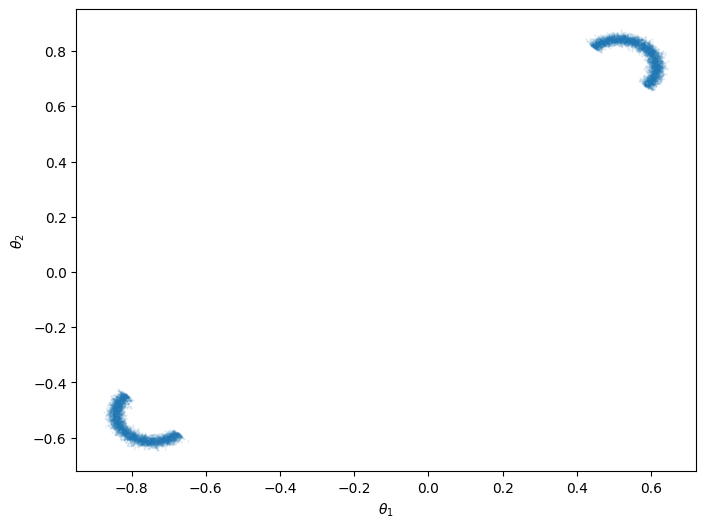

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(x=reference_samples[:, 0],
            y=reference_samples[:, 1],
            s=0.5,
            alpha=0.1)
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.show()

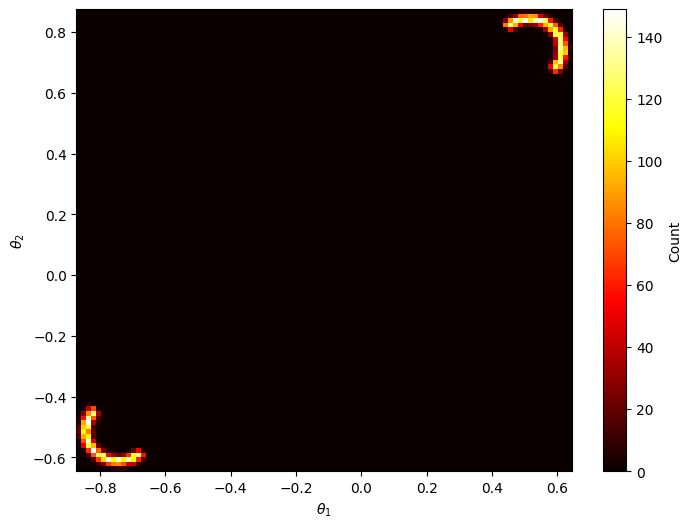

In [12]:
grid_size = 100

x_min, y_min = reference_samples.amin(axis=0)
x_max, y_max = reference_samples.amax(axis=0)

x_edges = np.linspace(x_min, x_max, grid_size + 1)
y_edges = np.linspace(y_min, y_max, grid_size + 1)

heatmap, _, _ = np.histogram2d(reference_samples[:, 0].numpy(), 
                               reference_samples[:, 1].numpy(), 
                               bins=[x_edges, y_edges])

plt.figure(figsize=(8, 6))
plt.imshow(heatmap.T, origin="lower", 
           extent=[x_min, x_max, y_min, y_max], 
           aspect="auto", cmap="hot")
plt.colorbar(label="Count")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.show()


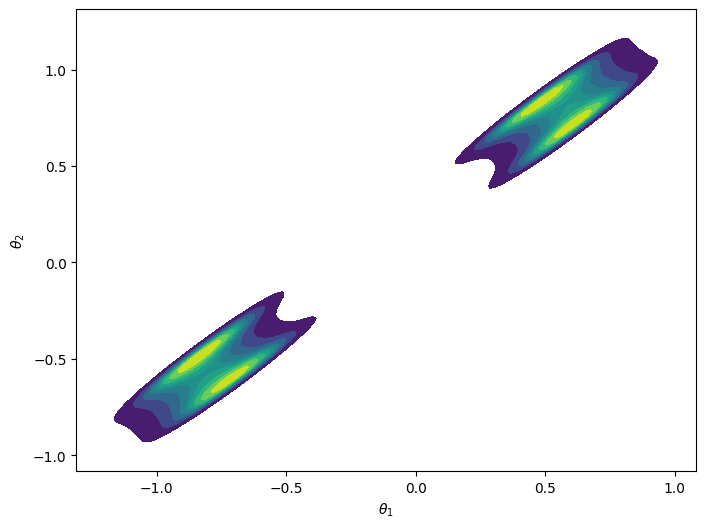

In [13]:
plt.figure(figsize=(8, 6))
sns.kdeplot(x=reference_samples[:, 0], 
            y=reference_samples[:, 1], 
            cmap="viridis", fill=True)
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.show()

In [14]:
del task, prior, simulator

### Train and Test NN

In [15]:
def compare_ref_and_est(task, obs_index, encoder, device):
    observation = task.get_observation(num_observation=obs_index)
    reference_samples = task.get_reference_posterior_samples(num_observation=obs_index)
    
    with torch.inference_mode():
        est_eta1, est_eta2 = encoder(observation.to(device=device))
        est_eta1 = est_eta1.squeeze(0)
        est_eta2 = est_eta2.squeeze(0)
    
    sigma2 = -1 / (2 * est_eta2)
    mu = est_eta1 * sigma2
    true_mu = reference_samples.mean(dim=0)

    return {
        "est_sigma2": sigma2,
        "est_mu": mu,
        "true_mu": true_mu,
    }

In [16]:
def train_and_test(seed, device):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    encoder = DenseEncoder1LayerGaussian(in_dim=2,
                                         out_dim=4,
                                         hidden_dim=1024).to(device=device)
    
    lr = 1e-4
    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr, amsgrad=True)
    scheduler = CustomOptim(optimizer, start_lr=lr)

    task = sbibm.get_task("two_moons")
    prior = task.get_prior()
    simulator = task.get_simulator()

    encoder = encoder.train()
    steps = int(1e4)
    batch_size = 64
    training_loss = []
    for _ in tqdm.tqdm(range(steps)):
        thetas = prior(num_samples=batch_size)
        xs = simulator(thetas)
        thetas, xs = thetas.to(device=device), xs.to(device=device)
        
        scheduler.zero_grad()
        loss = encoder.batch_favi_loss(thetas, xs)
        loss = loss.mean()
        loss.backward()
        scheduler.step_and_update_lr()

        training_loss.append(loss.item())

    encoder = encoder.eval()
    test_dict_list = [compare_ref_and_est(task, i + 1, encoder, device) 
                      for i in range(10)]

    return training_loss, test_dict_list

In [17]:
device = torch.device("cuda:7" if torch.cuda.is_available() else "cpu")

In [ ]:
training_loss, test_dict_list = train_and_test(seed=1234, device=device)

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(training_loss, linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

In [ ]:
for i, d in enumerate(test_dict_list):
    print(f"[{i + 1} / 10]")
    for k, v in d.items():
        print(f"{k}: {v}")
    print()

### Retrain and Test

In [18]:
model_num = 30
est_sigma2 = torch.zeros(model_num, 10, 2)
est_mu = torch.zeros(model_num, 10, 2)
true_mu = torch.zeros(model_num, 10, 2)
for i in range(model_num):
    print(f"Model [{i}] training")
    seed = random.Random(1234 + i).randint(10_000, 100_000)
    training_loss, test_dict_list = train_and_test(seed=seed, device=device)
    assert len(test_dict_list) == 10
    for obs_index in range(10):
        est_mu[i, obs_index] = test_dict_list[obs_index]["est_mu"].cpu()
        est_sigma2[i, obs_index] = test_dict_list[obs_index]["est_sigma2"].cpu()
        true_mu[i, obs_index] = test_dict_list[obs_index]["true_mu"].cpu()

Model [0] training


100%|██████████| 10000/10000 [00:52<00:00, 191.64it/s]


Model [1] training


100%|██████████| 10000/10000 [00:52<00:00, 191.50it/s]


Model [2] training


...

100%|██████████| 10000/10000 [00:50<00:00, 197.23it/s]


Model [28] training


100%|██████████| 10000/10000 [00:50<00:00, 196.48it/s]


Model [29] training


100%|██████████| 10000/10000 [00:50<00:00, 196.64it/s]


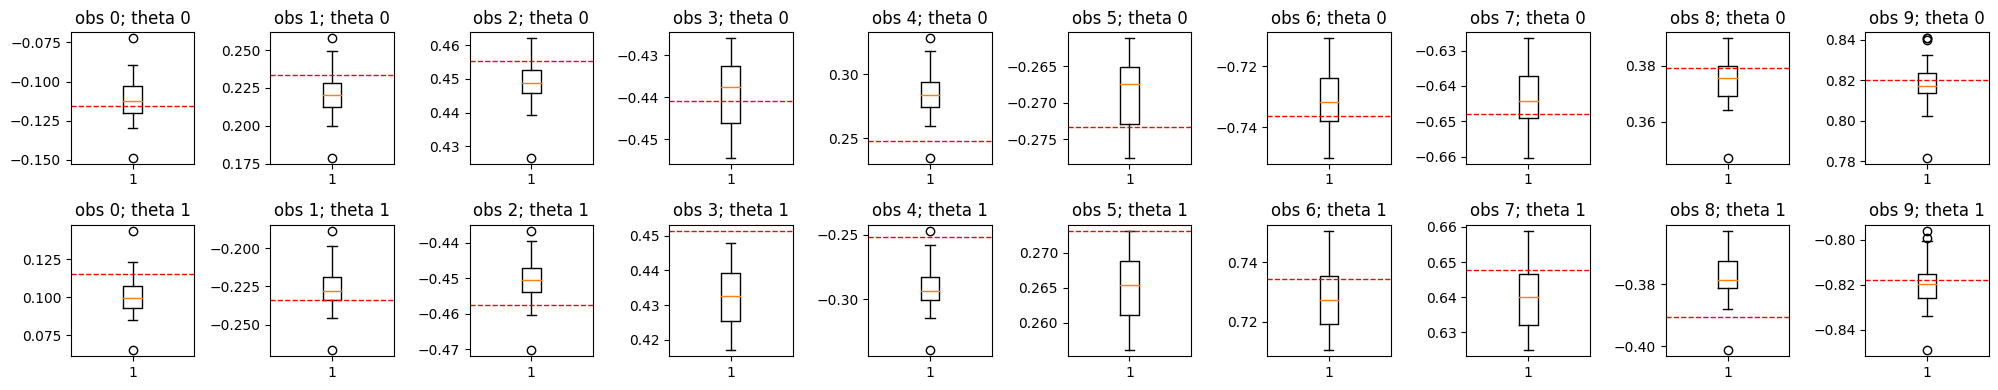

In [19]:
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.boxplot(est_mu[:, i % 10, i // 10])
    ax.axhline(y=true_mu[:, i % 10, i // 10].mean().item(), 
               color="r", linestyle="--", linewidth=1)
    ax.set_title(f"obs {i % 10}; theta {i // 10}")
fig.tight_layout()
fig.show()

In [ ]:
est_mu[:, 3, 0]

In [ ]:
true_mu